# Introduction to Pandas

**pandas** is a powerful Python library designed for working with structured data.  
Think of it as Excel — but programmable, much faster, and capable of handling millions of rows.

With pandas you can:
- **Read** datasets from CSV, Excel, SQL, and more
- **Clean** messy or incomplete data
- **Filter and select** specific rows or columns
- **Analyze** data using statistics and grouping
- **Visualize** data with built-in plotting

pandas is one of the most widely used tools in data science and is built on top of **NumPy**.

## 1. What is a Dataset?

A **dataset** is a structured collection of data, usually organized as rows and columns — like a spreadsheet.

| Name  | Age | City     |
|-------|-----|----------|
| Alice | 20  | Boston   |
| Bob   | 25  | Chicago  |
| Carol | 22  | New York |

Each **column** holds one type of information (e.g., age).  
Each **row** represents one record or observation (e.g., one student).

Datasets can contain:
- Numbers (`int`, `float`)
- Text (`string`)
- Dates and times (`datetime`)
- True/False values (`bool`)
- Missing values (`NaN`)


## 2. Importing pandas

Before using pandas, you need to import it.  
The convention is to import it as `pd` — this is used everywhere in practice.

But if it is not installed yet, run one of them in terminal (one is enough)

`pip install pandas`

`conda install pandas`

In [13]:
import pandas as pd
import numpy as np  # often used alongside pandas

## 3. The Two Core Data Structures

pandas has two main building blocks:

| Object      | Description                    | Analogy          |
|-------------|-------------------------------|------------------|
| `DataFrame` | A full table (rows & columns)  | Excel spreadsheet |
| `Series`    | A single column (or row)       | One column in Excel |

### 3a. DataFrame

A **DataFrame** is the primary pandas object — a 2D table with labeled rows and columns.  
You can create one from a dictionary, where each key is a column name and each value is a list of data.

In [14]:
# Creating a DataFrame from scratch
df = pd.DataFrame({
    "Name": ["Alice", "Bob", "Carol"],
    "Age":  [20, 25, 22],
    "City": ["Boston", "Chicago", "New York"]
})

print(df)

    Name  Age      City
0  Alice   20    Boston
1    Bob   25   Chicago
2  Carol   22  New York


In [15]:
# DataFrames render as a nice table in ipynb:
df

,Name,Age,City
0,Alice,20,Boston
1,Bob,25,Chicago
2,Carol,22,New York


### 3b. Series

A **Series** is a single column of data — like one column pulled from a DataFrame.  
It has an index (row labels) and values.

In [16]:
# Selecting one column returns a Series
ages = df["Age"]
print(ages)
print(type(ages))  # <class 'pandas.core.series.Series'>

0    20
1    25
2    22
Name: Age, dtype: int64
<class 'pandas.core.series.Series'>


In [17]:
# You can also create a Series directly
s = pd.Series([10, 20, 30, 40], index=["a", "b", "c", "d"])
print(s)

a    10
b    20
c    30
d    40
dtype: int64


## 4. Reading a Dataset

In practice, you almost never type data by hand. Instead, you **read it from a file**.  
The most common format is **CSV** (Comma-Separated Values).

We'll use a public dataset: [Students Performance in Exams](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)

If you are working on Kaggle, click `File` on the top left of the tool bar, then `Add input`. A small window on the right will pop up. In the search box, type `Students Performance in Exams`. After it shows up, click on the + sign below

In [18]:
# Read a CSV file into a DataFrame
# for now, put the CSV file in the same folder as this ipynb file
df = pd.read_csv("L04_StudentsPerformance.csv")

for people working in Kaggle, ignore the prvious cell and run this cell instead.

In [19]:
# for people not working in kaggle, ignore this cell

# df = pd.read_csv("/kaggle/input/datasets/spscientist/students-performance-in-exams/StudentsPerformance.csv")

In [20]:
# Reading an Excel file works the same way: (ignore this)
# df = pd.read_excel("file.xlsx")

## 5. Exploring a DataFrame

Once you've loaded a dataset, the first thing to do is **understand what's in it**.  
These functions give you a quick overview.

In [21]:
# View the first 5 rows (default)
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [22]:
# View the last 5 rows
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [23]:
# See a random sample of rows — useful for a quick gut-check
df.sample(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
703,female,group D,some college,standard,none,63,64,67
877,male,group C,some high school,standard,none,57,61,54
559,male,group D,some high school,standard,none,73,66,62
959,male,group C,high school,standard,none,75,81,71
44,female,group E,associate's degree,free/reduced,none,50,56,54


In [24]:
# Shape: (number of rows, number of columns)
df.shape

(1000, 8)

In [25]:
# List of all column names
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [26]:
# The row index (labels on the left side)
df.index

RangeIndex(start=0, stop=1000, step=1)

In [27]:
# Data types of each column
# int64 = integer, float64 = decimal, object = text
df.dtypes

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

In [28]:
# Summary: column names, data types, non-null counts, and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [29]:
# Statistical summary for all numeric columns:
# count, mean, std, min, 25%, 50%, 75%, max
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [30]:
# Include non-numeric columns in describe:
df.describe(include="all")

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
count,1000,1000,1000,1000,1000,1000.00000,1000.000000,1000.000000
unique,2,5,6,2,2,NaN,NaN,NaN
top,female,group C,some college,standard,none,NaN,NaN,NaN
freq,518,319,226,645,642,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,66.08900,69.169000,68.054000
std,NaN,NaN,NaN,NaN,NaN,15.16308,14.600192,15.195657
min,NaN,NaN,NaN,NaN,NaN,0.00000,17.000000,10.000000
25%,NaN,NaN,NaN,NaN,NaN,57.00000,59.000000,57.750000
50%,NaN,NaN,NaN,NaN,NaN,66.00000,70.000000,69.000000
75%,NaN,NaN,NaN,NaN,NaN,77.00000,79.000000,79.000000


## 6. Selecting Columns

You can extract one or more columns from a DataFrame using bracket notation.

In [31]:
# Select ONE column - returns a Series
df["math score"]

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math score, Length: 1000, dtype: int64

In [32]:
# Select MULTIPLE columns - returns a DataFrame
# Note: double brackets [[ ]]
df[["math score", "reading score", "writing score"]]

,math score,reading score,writing score
0,72,72,74
1,69,90,88
2,90,95,93
3,47,57,44
4,76,78,75
...,...,...,...
995,88,99,95
996,62,55,55
997,59,71,65
998,68,78,77


## 7. Selecting Rows

pandas provides two main ways to select rows:

| Method     | Selects by...        | Syntax           |
|------------|----------------------|-------------------|
| `.iloc[]`  | Integer position     | `df.iloc[row_selection, column_selection]` |
| `.loc[]`   | Label/Name  | `df.loc[row_label, column_label]` |

In [33]:
# iloc: select by integer position (0-based)
df.iloc[0]       # first row

gender                                    female
race/ethnicity                           group B
parental level of education    bachelor's degree
lunch                                   standard
test preparation course                     none
math score                                    72
reading score                                 72
writing score                                 74
Name: 0, dtype: object

In [34]:
df.iloc[0:3]     # first 3 rows (like Python slicing)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93


In [35]:
df.iloc[0, 1]    # row 0, column 1 

'group B'

In [36]:
df_abcd = pd.DataFrame(
    {
        "Name": ["Alice", "Bob", "Charlie", "David"],
        "Age": [25, 30, 22, 28],
        "Score": [90, 85, 95, 88]
    },
    index=["a", "b", "c", "d"]
)
df_abcd

,Name,Age,Score
a,Alice,25,90
b,Bob,30,85
c,Charlie,22,95
d,David,28,88


In [37]:
# label = row indexing
# loc: select by label
df_abcd.loc['a'] # row where index == 0

Name     Alice
Age         25
Score       90
Name: a, dtype: object

In [38]:
# loc with row and column label
df_abcd.loc['a', "Name"]

'Alice'

## 8. Filtering Rows

**Filtering** lets you keep only rows that match a condition.  
This works by passing a boolean expression inside the brackets.

In [39]:
# Keep only rows where math score > 80
df[df["math score"] > 80]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
2,female,group B,master's degree,standard,none,90,95,93
6,female,group B,some college,standard,completed,88,95,92
16,male,group C,high school,standard,none,88,89,86
34,male,group E,some college,standard,none,97,87,82
35,male,group E,associate's degree,standard,completed,81,81,79
...,...,...,...,...,...,...,...,...
979,female,group C,associate's degree,standard,none,91,95,94
981,male,group D,some high school,standard,none,81,78,78
987,male,group E,some high school,standard,completed,81,75,76
990,male,group E,high school,free/reduced,completed,86,81,75


In [40]:
# Combine conditions with & (AND) and | (OR)
# Parentheses are required around each condition!
df[(df["math score"] > 80) & (df["gender"] == "female")]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
2,female,group B,master's degree,standard,none,90,95,93
6,female,group B,some college,standard,completed,88,95,92
56,female,group E,associate's degree,standard,completed,82,85,86
102,female,group D,associate's degree,standard,none,85,91,89
106,female,group D,master's degree,standard,none,87,100,100
...,...,...,...,...,...,...,...,...
957,female,group D,master's degree,standard,none,92,100,100
962,female,group E,associate's degree,standard,none,100,100,100
970,female,group D,bachelor's degree,standard,none,89,100,100
979,female,group C,associate's degree,standard,none,91,95,94


In [41]:
# Filter using .isin() — match any value in a list
df[df["race/ethnicity"].isin(["group A", "group B"])]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
...,...,...,...,...,...,...,...,...
983,female,group A,some college,standard,completed,78,87,91
985,male,group A,high school,standard,none,57,51,54
988,female,group A,some high school,free/reduced,none,44,45,45
991,female,group B,some high school,standard,completed,65,82,78


In [42]:
# Filter using .str.contains() — text matching
df[df["lunch"].str.contains("standard")]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
...,...,...,...,...,...,...,...,...
987,male,group E,some high school,standard,completed,81,75,76
991,female,group B,some high school,standard,completed,65,82,78
994,male,group A,high school,standard,none,63,63,62
995,female,group E,master's degree,standard,completed,88,99,95


## 9. Adding and Modifying Columns

You can create new columns by assigning values to a new column name.

In [43]:
df["math score plus one"] = df['math score'] + 1
df[["math score plus one", "math score"]].head()

,math score plus one,math score
0,73,72
1,70,69
2,91,90
3,48,47
4,77,76


In [44]:
# Add a new column: average of all three scores
df["average score"] = (df["math score"] + df["reading score"] + df["writing score"]) / 3

df[["math score", "reading score", "writing score", "average score"]].head()

,math score,reading score,writing score,average score
0,72,72,74,72.666667
1,69,90,88,82.333333
2,90,95,93,92.666667
3,47,57,44,49.333333
4,76,78,75,76.333333


In [45]:
# Add a categorical column using a condition
df["passed"] = df["math score"] >= 60

df[["math score", "passed"]].head()

,math score,passed
0,72,True
1,69,True
2,90,True
3,47,False
4,76,True


In [46]:
# Use np.where for if/else column creation
# np.where(condition, value_if_true, value_if_false)
df["grade"] = np.where(df["math score"] >= 60, "Pass", "Fail")

df[["math score", "grade"]].head()

,math score,grade
0,72,Pass
1,69,Pass
2,90,Pass
3,47,Fail
4,76,Pass


In [47]:
# Rename columns
# inplace=True means modify the existing DataFrame directly instead of creating and returning a new DataFrame.
# Without inplace=True we are creating a new dataframe instead of modifying df
df.rename(columns={"race/ethnicity": "ethnicity"}, inplace=True)
df.columns

Index(['gender', 'ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'math score plus one', 'average score', 'passed',
       'grade'],
      dtype='object')

In [48]:
# Drop a column you no longer need
# errors="ignore" mean If the column you're trying to drop doesn't exist, don't raise an error. Just continue.
df.drop(columns=["math score plus one"], errors="ignore", inplace=True)
df.columns

Index(['gender', 'ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'average score', 'passed', 'grade'],
      dtype='object')

## 10. Sorting

`sort_values()` lets you reorder rows based on the values in one or more columns.

In [49]:
# Sort by math score, lowest to highest (ascending, default)
df.sort_values("math score").head()

,gender,ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average score,passed,grade
59,female,group C,some high school,free/reduced,none,0,17,10,9.000000,False,Fail
980,female,group B,high school,free/reduced,none,8,24,23,18.333333,False,Fail
17,female,group B,some high school,free/reduced,none,18,32,28,26.000000,False,Fail
787,female,group B,some college,standard,none,19,38,32,29.666667,False,Fail
145,female,group C,some college,free/reduced,none,22,39,33,31.333333,False,Fail


In [50]:
# Sort by math score, highest to lowest (descending)
df.sort_values("math score", ascending=False).head()

,gender,ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average score,passed,grade
962,female,group E,associate's degree,standard,none,100,100,100,100.000000,True,Pass
625,male,group D,some college,standard,completed,100,97,99,98.666667,True,Pass
458,female,group E,bachelor's degree,standard,none,100,100,100,100.000000,True,Pass
623,male,group A,some college,standard,completed,100,96,86,94.000000,True,Pass
451,female,group E,some college,standard,none,100,92,97,96.333333,True,Pass


In [51]:
# Sort by multiple columns
# First by gender, then by math score descending
df.sort_values(["gender", "math score"], ascending=[True, False]).head()

,gender,ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average score,passed,grade
451,female,group E,some college,standard,none,100,92,97,96.333333,True,Pass
458,female,group E,bachelor's degree,standard,none,100,100,100,100.000000,True,Pass
962,female,group E,associate's degree,standard,none,100,100,100,100.000000,True,Pass
114,female,group E,bachelor's degree,standard,completed,99,100,100,99.666667,True,Pass
263,female,group E,high school,standard,none,99,93,90,94.000000,True,Pass


## 11. Summary Statistics

pandas makes it easy to compute common statistics on a column or the whole DataFrame.

In [52]:
# Basic statistics on a single column
print("Mean:  ", df["math score"].mean())
print("Median:", df["math score"].median())
print("Std:   ", df["math score"].std())
print("Min:   ", df["math score"].min())
print("Max:   ", df["math score"].max())

Mean:   66.089
Median: 66.0
Std:    15.163080096009468
Min:    0
Max:    100


In [53]:
# Count how many times each unique value appears
df["gender"].value_counts()

gender
female    518
male      482
Name: count, dtype: int64

In [54]:
# Count unique values
df["ethnicity"].nunique()

5

In [55]:
# List all unique values in a column
df["ethnicity"].unique()

array(['group B', 'group C', 'group A', 'group D', 'group E'],
      dtype=object)

### Exercise

In [56]:
edf01 = pd.DataFrame({
    "Name": ["Alice", "Bob", "Charlie", "David", "Eva"],
    "Age": [20, 21, 19, 22, 20],
    "Major": ["DS", "CS", "DS", "Math", "CS"],
    "GPA": [3.8, 3.5, 3.9, 3.2, 3.7]
})

#### Inspect the Data: 

Display the first 3 rows.

Display the last 2 rows.

Find the number of rows and columns.

Display all column names.

#### Select Data
Select only the Name column.

Select Name and GPA.

Get the first row.

Get the third row.

#### Filter Rows

Find students with GPA > 3.7.

Find CS majors.

Find students aged 20.

#### Create New Columns

Create a column called Honor Roll (True if GPA ≥ 3.7 and False if GPA < 3.7).

## 12. Group By

`groupby()` splits the DataFrame into groups based on a column, then lets you apply an operation (like `mean()`) to each group.

Think of it as: **"For each category, compute something."**

![GroupBy illustration](https://learnsql.com/blog/group-by-in-sql-explained/GROUP_BY-avg.jpg)

In [57]:
df.head()

,gender,ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average score,passed,grade
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,True,Pass
1,female,group C,some college,standard,completed,69,90,88,82.333333,True,Pass
2,female,group B,master's degree,standard,none,90,95,93,92.666667,True,Pass
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,False,Fail
4,male,group C,some college,standard,none,76,78,75,76.333333,True,Pass


In [58]:
# Average math score by ethnicity group
df.groupby("ethnicity")["math score"].mean()

ethnicity
group A    61.629213
group B    63.452632
group C    64.463950
group D    67.362595
group E    73.821429
Name: math score, dtype: float64

In [59]:
# Apply multiple aggregations at once
df.groupby("gender")["math score"].agg(["mean", "median", "count"])

,mean,median,count
gender,,,
female,63.633205,65.0,518
male,68.728216,69.0,482


In [60]:
# Group by multiple columns
df.groupby(["gender", "ethnicity"])["math score"].mean()

gender  ethnicity
female  group A      58.527778
        group B      61.403846
        group C      62.033333
        group D      65.248062
        group E      70.811594
male    group A      63.735849
        group B      65.930233
        group C      67.611511
        group D      69.413534
        group E      76.746479
Name: math score, dtype: float64

In [61]:
# Count rows per group using size()
df.groupby("lunch").size()

lunch
free/reduced    355
standard        645
dtype: int64

#### Exercise

In [86]:
edf01 = pd.DataFrame({
    "Name": ["Alice", "Bob", "Charlie", "David", "Eva"],
    "Age": [20, 21, 19, 22, 20],
    "Major": ["DS", "CS", "DS", "Math", "CS"],
    "GPA": [3.8, 3.5, 3.9, 3.2, 3.7]
})

#### GroupBy Exercises

Average GPA by Major.

Maximum GPA by Major.

Number of students in each Major.

## 13. Missing Values

Real-world data is often incomplete. pandas stores missing values as **`NaN`** (Not a Number).

| Name  | Age  |
|-------|------|
| Alice | 20   |
| Bob   | NaN  |

Always check for missing values before analyzing data — they can silently affect your results.

In [92]:
df2 = pd.DataFrame({
    "Name": ["Alice", "Bob", None, "David", "Eva"],
    "Age": [20, None, 19, 22, 21],
    "Major": ["DS", "CS", "Math", None, "CS"],
    "GPA": [3.8, 3.5, None, 3.2, 3.9]
})

df2

,Name,Age,Major,GPA
0,Alice,20.0,DS,3.8
1,Bob,NaN,CS,3.5
2,None,19.0,Math,NaN
3,David,22.0,None,3.2
4,Eva,21.0,CS,3.9


In [88]:
# Count missing values per column
df2.isna().sum()

Name     1
Age      1
Major    1
GPA      1
dtype: int64

In [89]:
# What percentage of each column is missing?
(df2.isna().sum() / len(df2) * 100).round(2)

Name     20.0
Age      20.0
Major    20.0
GPA      20.0
dtype: float64

In [93]:
# Drop ALL rows that have any missing value
df_clean = df2.dropna()
print(df_clean.shape)
df_clean

(2, 4)


,Name,Age,Major,GPA
0,Alice,20.0,DS,3.8
4,Eva,21.0,CS,3.9


In [98]:
# Fill missing values with a specific value
df_filled = df2.fillna(0)          # fill with 0
df_filled

,Name,Age,Major,GPA
0,Alice,20.0,DS,3.8
1,Bob,20.5,CS,3.5
2,0,19.0,Math,0.0
3,David,22.0,0,3.2
4,Eva,21.0,CS,3.9


In [101]:
# Fill with the column mean
df2["Age"] = df2["Age"].fillna(df2["Age"].mean())
df2

,Name,Age,Major,GPA
0,Alice,20.0,DS,3.8
1,Bob,20.5,CS,3.5
2,None,19.0,Math,NaN
3,David,22.0,None,3.2
4,Eva,21.0,CS,3.9


In [97]:
# Fill forward (carry the previous value down)
# It copies the previous non-missing value downward.
df2.ffill().head()

,Name,Age,Major,GPA
0,Alice,20.0,DS,3.8
1,Bob,20.5,CS,3.5
2,Bob,19.0,Math,3.5
3,David,22.0,Math,3.2
4,Eva,21.0,CS,3.9


## 14. Applying Functions

`apply()` lets you run a custom function on each value, row, or column.  
This is useful when built-in operations aren't enough.

`lambda` is a short, anonymous function (a function without a name).

lambda syntax: `lambda parameter: expression`

``` python
ex: lambda x: x + 1
equivalent to:
def add_one(x):
    return x + 1
```

In [67]:
# Apply a function to a column (element-wise)
# returns a new Series with the results
# For each value x in the "math score" column, return "High" if x >= 80, otherwise return "Low".
df["math score"].apply(lambda x: "High" if x >= 80 else "Low")

0       Low
1       Low
2      High
3       Low
4       Low
       ... 
995    High
996     Low
997     Low
998     Low
999     Low
Name: math score, Length: 1000, dtype: object

``` python
lambda x: "High" if x >= 80 else "Low"
```
is equivalent to
``` python
def classify(x):
    if x >= 80:
        return "High"
    else:
        return "Low"
```

In [68]:
# Apply a named function
def letter_grade(score):
    if score >= 90: return "A"
    elif score >= 80: return "B"
    elif score >= 70: return "C"
    elif score >= 60: return "D"
    else: return "F"

df["math grade"] = df["math score"].apply(letter_grade)
df[["math score", "math grade"]].head(10)

,math score,math grade
0,72,C
1,69,D
2,90,A
3,47,F
4,76,C
5,71,C
6,88,B
7,40,F
8,64,D
9,38,F


#### Exercise

In [102]:
df3 = pd.DataFrame({
    "Name": ["Alice", "Bob", "Charlie", "David", "Eva", "Frank", "Grace", "Henry"],
    "Age": [18, 19, 18, 20, 19, 18, 21, 20],
    "Major": ["DS", "CS", "Math", "DS", "CS", "Math", "DS", "CS"],
    "Math Score": [95, 82, 68, 74, 91, 58, 87, 79],
    "Reading Score": [90, 85, 72, 80, 93, 60, 89, 77],
    "Writing Score": [92, 81, 70, 78, 95, 55, 90, 75]
})

print(df3)

      Name  Age Major  Math Score  Reading Score  Writing Score
0    Alice   18    DS          95             90             92
1      Bob   19    CS          82             85             81
2  Charlie   18  Math          68             72             70
3    David   20    DS          74             80             78
4      Eva   19    CS          91             93             95
5    Frank   18  Math          58             60             55
6    Grace   21    DS          87             89             90
7    Henry   20    CS          79             77             75


Create a function that assigns a letter grade:

| Average Score | Grade |
| ------------- | ----- |
| 90+           | A     |
| 80-89         | B     |
| 70-79         | C     |
| 60-69         | D     |
| Below 60      | F     |

Task:

Write a function called:

``` python
def letter_grade(score):
    pass
```

Then create a new column:

``` python
df["Writing Grade"] = df["Writing Score"].apply(letter_grade)
``` 

## 15. Merging and Combining DataFrames

When data is split across multiple files or tables, you need to combine them.

| Function     | What it does                              |
|--------------|-------------------------------------------|
| `pd.concat()`| Stack DataFrames vertically or horizontally |
| `pd.merge()` | Join DataFrames on a shared column |

In [69]:
# Concatenate (stack) two DataFrames vertically
df1 = pd.DataFrame({"Name": ["Alice", "Bob"], "Score": [90, 85]})
df2 = pd.DataFrame({"Name": ["Carol", "Dave"], "Score": [78, 92]})
print(df1)
print(df2)

    Name  Score
0  Alice     90
1    Bob     85
    Name  Score
0  Carol     78
1   Dave     92


In [70]:
combined = pd.concat([df1, df2], ignore_index=True)
print(combined)

    Name  Score
0  Alice     90
1    Bob     85
2  Carol     78
3   Dave     92


In [71]:
# Merge (join) two DataFrames on a shared column
students = pd.DataFrame({"ID": [1, 2, 3], "Name": ["Alice", "Bob", "Carol"]})
scores   = pd.DataFrame({"ID": [1, 2, 3], "Math": [90, 85, 78]})
print(students)
print(scores)

   ID   Name
0   1  Alice
1   2    Bob
2   3  Carol
   ID  Math
0   1    90
1   2    85
2   3    78


pandas matches rows where ID exists in both tables<br>
say ID=3 only exists in students and ID=4 only exists in scores, those rows are dropped<br>
say ID=2 exists both in students and in scores, those rows are kept<br>
This default behavior is called an `inner join`.

In [72]:
# inner join (default)
merged = pd.merge(students, scores, on="ID")
print(merged)

   ID   Name  Math
0   1  Alice    90
1   2    Bob    85
2   3  Carol    78


In [73]:
# inner join (default) — only keep rows with matching IDs in both DataFrames
pd.merge(students, scores, on="ID", how="inner")

,ID,Name,Math
0,1,Alice,90
1,2,Bob,85
2,3,Carol,78


In [74]:
# left join — keep all rows from the left DataFrame, and match from the right
# If there is no match in the right DataFrame, the new columns will have NaN values.
pd.merge(students, scores, on="ID", how="left")

,ID,Name,Math
0,1,Alice,90
1,2,Bob,85
2,3,Carol,78


In [75]:
# right join — keep all rows from the right DataFrame, and match from the left
pd.merge(students, scores, on="ID", how="right")

,ID,Name,Math
0,1,Alice,90
1,2,Bob,85
2,3,Carol,78


In [76]:
# outer join — keep all rows from both DataFrames, and match where possible
pd.merge(students, scores, on="ID", how="outer")

,ID,Name,Math
0,1,Alice,90
1,2,Bob,85
2,3,Carol,78


| Join Type | Keeps                 |
| --------- | --------------------- |
| inner     | overlap only          |
| left      | everything from left  |
| right     | everything from right |
| outer     | everything from both  |


## 16. Exporting Data

Once you've cleaned or analyzed your data, you can save it back to a file.<br>
`to_csv()` worked because CSV support is built into pandas.<br>
But Excel files need an additional library `openpyxl`
```
conda install conda-forge::openpyxl
```

In [ ]:
# Save to CSV (index=False prevents writing the row numbers as a column)
df.to_csv("output.csv", index=False)

# Save to Excel
df.to_excel("output.xlsx", index=False)

print("Files saved!")

Files saved!


## 17. Plotting (Optional reading)

pandas has built-in plotting methods

we normally only use pandas for simple drawing 

Under the hood, pandas uses `Matplotlib` to actually draw the charts.

#### `df.plot()`
Creates a line chart by default.
- X-axis - dataframe index
- Y-axis - numeric columns

<Axes: >

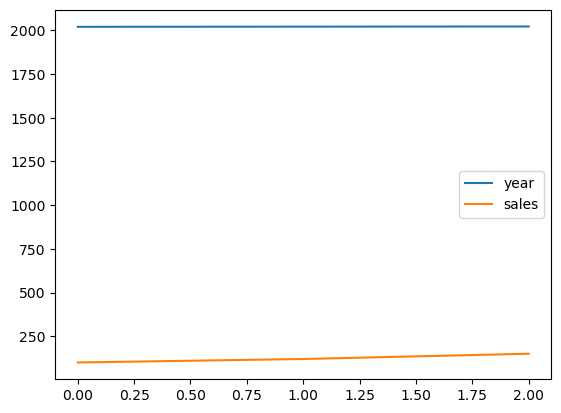

In [78]:
df = pd.DataFrame({
    "year": [2020, 2021, 2022],
    "sales": [100, 120, 150]
})

df.plot()

Important Inputs
| Input           | Meaning       |
| --------------- | ------------- |
| `kind`          | chart type    |
| `figsize=(w,h)` | chart size    |
| `title="..."`   | chart title   |
| `x="col"`       | choose x-axis |
| `y="col"`       | choose y-axis |
| `grid=True`     | show grid     |
| `legend=True`   | show legend   |


<Axes: title={'center': 'Sales Over Time'}, xlabel='year'>

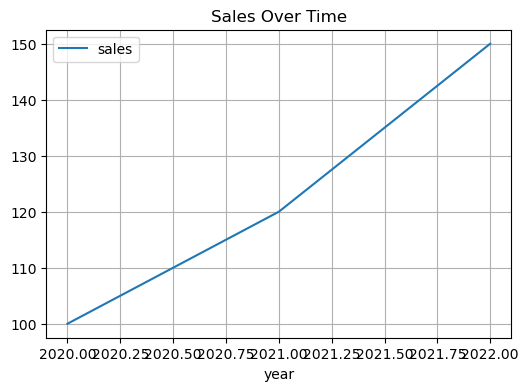

In [79]:
df.plot(
    x="year",
    y="sales",
    title="Sales Over Time",
    figsize=(6,4),
    grid=True
)

#### `df.hist()`
Creates a histogram<br>
A histogram shows:
- how values are distributed
- how often values appear

array([[<Axes: title={'center': 'age'}>]], dtype=object)

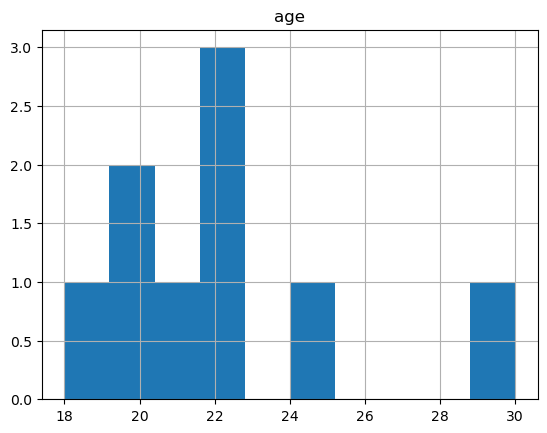

In [80]:
df = pd.DataFrame({
    "age": [18,20,20,21,22,22,22,25,30]
})

df.hist()

Important Inputs
| Input           | Meaning                  |
| --------------- | ------------------------ |
| `bins=10`       | number of groups/buckets |
| `figsize=(w,h)` | figure size              |
| `column="age"`  | choose column            |
| `grid=True`     | show grid                |


array([[<Axes: title={'center': 'age'}>]], dtype=object)

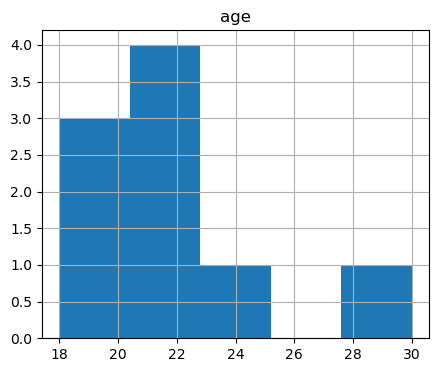

In [81]:
df.hist(
    column="age",
    bins=5,
    figsize=(5,4)
)

#### `df.plot(kind="bar")`
Creates a bar chart<br>
Used for comparing categories

<Axes: xlabel='fruit'>

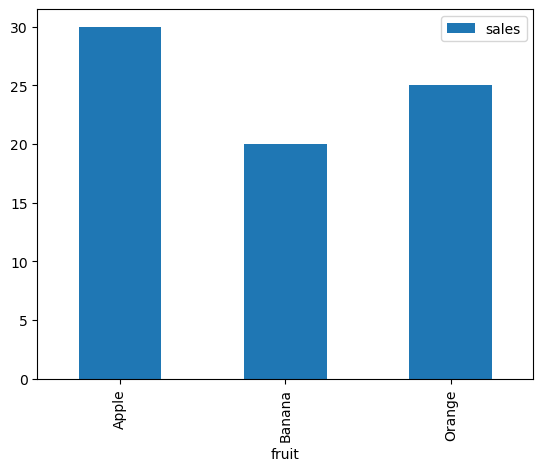

In [82]:
df = pd.DataFrame({
    "fruit": ["Apple", "Banana", "Orange"],
    "sales": [30, 20, 25]
})

df.plot(
    kind="bar",
    x="fruit",
    y="sales"
)

Important Inputs
| Input          | Meaning         |
| -------------- | --------------- |
| `x="col"`      | category column |
| `y="col"`      | value column    |
| `stacked=True` | stack bars      |
| `rot=45`       | rotate labels   |


<Axes: >

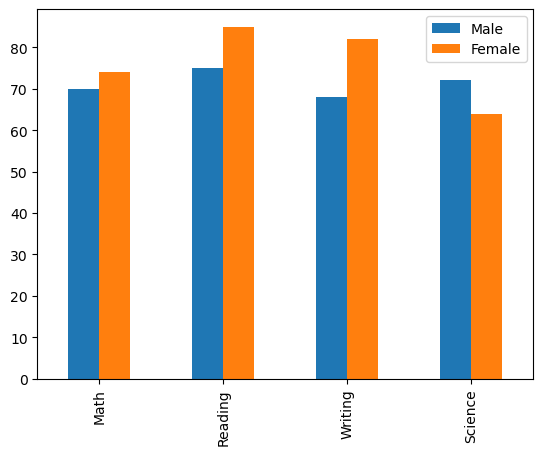

In [83]:
# Grouped bar chart — comparing two groups side by side using pandas DataFrame
subjects = ["Math", "Reading", "Writing", "Science"]
male_scores   = [70, 75, 68, 72]
female_scores = [74, 85, 82, 64]

df = pd.DataFrame({
    "Male": male_scores,
    "Female": female_scores
}, index=subjects)

df.plot(kind="bar")

#### `df.plot(kind="scatter", x="a", y="b")`
Creates a scatter plot<br>
Used to see relationships between two numeric columns.

<Axes: xlabel='height', ylabel='weight'>

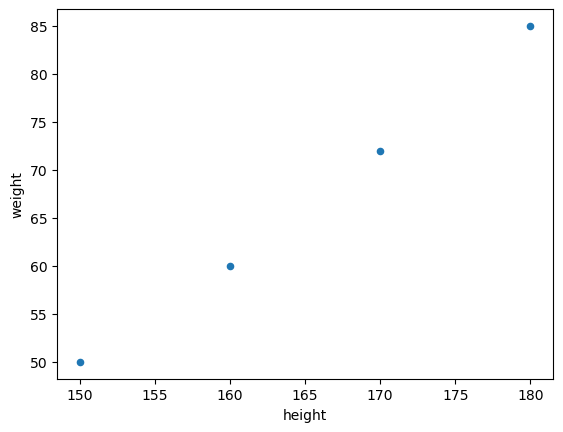

In [84]:
df = pd.DataFrame({
    "height": [150,160,170,180],
    "weight": [50,60,72,85]
})

df.plot(
    kind="scatter",
    x="height",
    y="weight"
)

Important Inputs
| Input       | Meaning       |
| ----------- | ------------- |
| `x="col"`   | x-axis column |
| `y="col"`   | y-axis column |
| `s=100`     | point size    |
| `alpha=0.5` | transparency  |


<Axes: xlabel='height', ylabel='weight'>

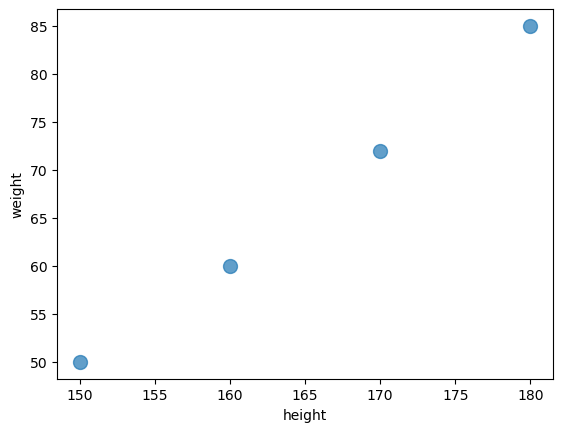

In [85]:
df.plot(
    kind="scatter",
    x="height",
    y="weight",
    s=100,
    alpha=0.7
)

Summary
| Code                      | Chart Type   | Purpose                        |
| ------------------------- | ------------ | ------------------------------ |
| `df.plot()`               | Line chart   | trends over time               |
| `df.hist()`               | Histogram    | distribution/frequency         |
| `df.plot(kind="bar")`     | Bar chart    | compare categories             |
| `df.plot(kind="scatter")` | Scatter plot | relationship between variables |


## 18. Quick Reference Summary

| Concept            | Code Example                          | What it does                          |
|--------------------|---------------------------------------|---------------------------------------|
| Import             | `import pandas as pd`                 | Load the pandas library               |
| Read CSV           | `pd.read_csv("file.csv")`             | Load data from a CSV file             |
| Preview top        | `df.head()`                           | Show first 5 rows                     |
| Preview bottom     | `df.tail()`                           | Show last 5 rows                      |
| Shape              | `df.shape`                            | (rows, columns) count                 |
| Column types       | `df.dtypes`                           | Data type of each column              |
| Summary stats      | `df.describe()`                       | Count, mean, std, min/max, quartiles  |
| Select column      | `df["col"]`                           | Returns a Series                      |
| Select columns     | `df[["col1", "col2"]]`               | Returns a DataFrame                   |
| Row by position    | `df.iloc[0]`                          | First row by integer index            |
| Row by label       | `df.loc[0]`                           | Row where index == 0                  |
| Filter rows        | `df[df["col"] > 50]`                  | Keep rows matching a condition        |
| Add column         | `df["new"] = df["a"] + df["b"]`       | Compute a new column                  |
| Sort               | `df.sort_values("col")`               | Sort rows by column value             |
| Group by           | `df.groupby("col").mean()`            | Aggregate by category                 |
| Value counts       | `df["col"].value_counts()`            | Count occurrences of each value       |
| Missing values     | `df.isna().sum()`                     | Count NaN per column                  |
| Drop missing       | `df.dropna()`                         | Remove rows with any NaN              |
| Fill missing       | `df.fillna(0)`                        | Replace NaN with a value              |
| Apply function     | `df["col"].apply(func)`               | Run a function on each value          |
| Rename columns     | `df.rename(columns={"old": "new"})`   | Rename one or more columns            |
| Drop column        | `df.drop(columns=["col"])`            | Remove a column                       |
| Merge              | `pd.merge(df1, df2, on="id")`         | Join two DataFrames on a key          |
| Concat             | `pd.concat([df1, df2])`               | Stack DataFrames                      |
| Export CSV         | `df.to_csv("out.csv", index=False)`   | Save DataFrame to a file              |
| Plot               | `df.plot`         | Quick visualization                   |